In [108]:
%matplotlib inline

In [ ]:
import os
import struct

from plot.color import Color
from plot.formatter import LabelFormatter, NumberFormatter, Scale, Grid, LambdaFormatter, Decorator, PercentFormatter
from plot.frame import latexify, cm2inch, Format, GridFrame, SingleFrame
from plot.boxplot import BoxPlot
from plot.barplot import BarPlot
from plot.lineplot import LinePlot
from plot.linestyle import Linestyle
from plot.location import Location
from plot.marker import Marker
from matplotlib.lines import Line2D


In [ ]:
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

from eval_utils import (
    load_model_results,
    lift_compression_args,
    include_peft,
    add_rank,
)

In [111]:
# ---- Notebook parameters ----
#results_file = "compression_results.json" 
results_file = "/home/neubauer/src/comp-economics/compression_results.json"

x_col = "total_params"
y_col = "compression_factor"

save_path = "plot.png"  # set to None to not save

In [112]:
print(f"Loading results from {results_file}")
dict_results = load_model_results(results_file)

# Lift compression args to top level
dict_results = {
    k: lift_compression_args(v)
    for k, v in dict_results.items()
}

# Drop compression nesting for easier plotting
dict_results = {
    k: v.get("compression", {})
    for k, v in dict_results.items()
}

# Infer PEFT type (lora / vera / None)
dict_results = include_peft(dict_results)
dict_results = add_rank(dict_results)

print(f"Loaded {len(dict_results)} runs")


#TODO: handle quantization

Loading results from /home/neubauer/src/comp-economics/compression_results.json
{'text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100000|kv=True|batch=16|reduce=True|engine=transformer|enc=AC|lora=./adapters/vera/text8/r4_lr0.0005_lsconstant_bs64_ep4_gas2/': {'compression': {'args': {'mode': 'compress', 'input_path': './data/text8', 'output_path': 'compression_data.bin', 'model_name': 'Qwen/Qwen2.5-0.5B', 'lora_path': './adapters/vera/text8/r4_lr0.0005_lsconstant_bs64_ep4_gas2/', 'context_length': 1000, 'retain_tokens': 100, 'first_n_tokens': 100000, 'use_kv_cache': True, 'text_input': None, 'reduce_tokens': True, 'batch_size': 16, 'engine': 'transformer', 'encoding': 'AC', 'print_results': False}, 'chunk_length': 6250, 'chunk_size': -1, 'original_size_bytes': 532654, 'arithmetic_code_size_bytes': 59993.0, 'bitmap_size_bytes': 10818.0, 'final_size_bytes': 70811.0, 'pure_compression_factor': 8.878602503625423, 'compression_factor': 7.522192879637345, 'input_tokens_count': 53263600, 'entropy'

In [113]:
with open("loaded_results.json", "w") as f:
    json.dump(dict_results, f, indent=2)

print("Saved normalized results to loaded_results.json")

Saved normalized results to loaded_results.json


In [114]:
df = pd.DataFrame.from_dict(dict_results, orient="index")
df = df.reset_index().rename(columns={"index": "run_key"})

# replace NaNs with 0
df = df.fillna(0)

# replace 'huffman' with 'HC' in encoding column and 'bitpacked' with 'BP'
df["encoding"] = df["encoding"].replace({"huffman": "HC"})
df["encoding"] = df["encoding"].replace({"bitpacked": "BP"})

df.head(5)

,run_key,chunk_length,chunk_size,original_size_bytes,arithmetic_code_size_bytes,bitmap_size_bytes,final_size_bytes,pure_compression_factor,compression_factor,input_tokens_count,...,first_n_tokens,use_kv_cache,text_input,reduce_tokens,batch_size,engine,encoding,print_results,peft,rank
0,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,59993.000,10818.0,70811.000,8.878603,7.522193,53263600,...,100000,True,0,True,16,transformer,AC,False,vera,4.0
1,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60163.375,10818.0,70981.375,8.853459,7.504138,53263600,...,100000,True,0,True,16,transformer,AC,False,vera,4.0
2,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60088.375,10818.0,70906.375,8.864510,7.512075,53263600,...,100000,True,0,True,16,transformer,AC,False,vera,8.0
3,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60042.875,10818.0,70860.875,8.871227,7.516898,53263600,...,100000,True,0,True,16,transformer,AC,False,vera,16.0
4,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,59646.750,10818.0,70464.750,8.930143,7.559155,53263600,...,100000,True,0,True,16,transformer,AC,False,vera,64.0


In [115]:
# print all column names
print("Columns in DataFrame:", df.columns.tolist())

Columns in DataFrame: ['run_key', 'chunk_length', 'chunk_size', 'original_size_bytes', 'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'final_size_bytes', 'pure_compression_factor', 'compression_factor', 'input_tokens_count', 'entropy', 'total_compression_time', 'tokenize_time', 'compression_time', 'inference_time', 'ac_time', 'data_copy_time', 'softmax_time', 'throughput_tokens_per_sec', 'throughput_kibibytes_per_sec', 'inference_throughput_tokens_per_sec', 'inference_throughput_kibibytes_per_sec', 'total_params', 'adapter_params', 'base_model_params', 'total_size_mb', 'adapter_size_mb', 'base_model_size_mb', 'mode', 'input_path', 'output_path', 'model_name', 'lora_path', 'context_length', 'retain_tokens', 'first_n_tokens', 'use_kv_cache', 'text_input', 'reduce_tokens', 'batch_size', 'engine', 'encoding', 'print_results', 'peft', 'rank']


In [116]:
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

In [117]:
LABELS = {
    "total_params": "Model Parameters",
    "compression_factor": "Compression Ratio",
    "pure_compression_factor": "Pure Compression Ratio",

    "adapter_params": "Adapter Parameters",
    "base_model_params": "Base Model Parameters",
    "base_model_size_mb": "Base Model Size (MB)",
    "adapter_size_mb": "Adapter Size (MB)",

    "throughput_kibibytes_per_sec": "Compression Throughput (KiB/s)",
    "final_size_bytes": "Compressed Size (bytes)",
    "peft": "PEFT Method",
    "encoding": "Encoding Method",
    "rank": "Rank (r) of Adapters (if applicable)",
}

SCALES = {
    "total_params": "log",
    "throughput_kibibytes_per_sec": "log",
    "final_size_bytes": "log",
}

# --- Define color/marker mappings ---
COLOR_BY_PEFT = {
    None: "tab:gray",
    "lora": "tab:blue",
    "vera": "tab:orange",
}

MARKER_BY_ENCODING = {
    "AC": "o",
    "HC": "s",
    "BP": "D",
    None: "x",
}

def pretty_label(col):
    return LABELS.get(col, col.replace("_", " ").title())

Saved plot to plot.png


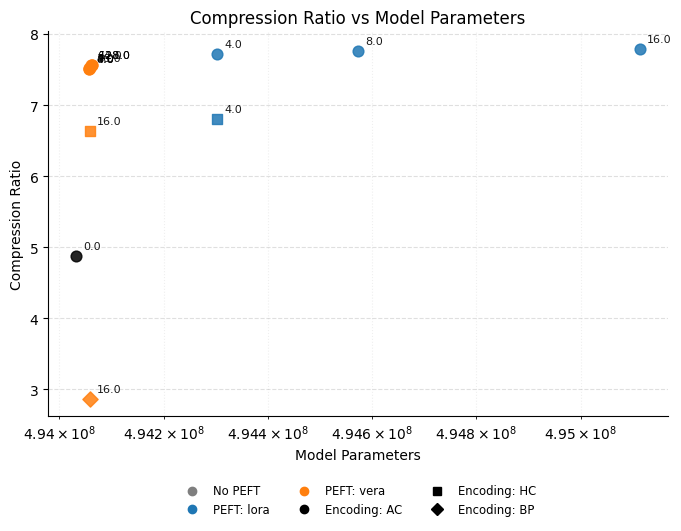

In [118]:
# --- Setup ---
plt.figure(figsize=(8, 5))
ax = plt.gca()

# --- Plot each run with semantic encodings ---
for _, r in df.iterrows():
    x = r[x_col]
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=60,
        alpha=0.85,
    )

    # --- Add rank label ---
    ax.annotate(
        str(r["rank"]),          # convert to string
        (x, y),                  # position
        textcoords="offset points",
        xytext=(5, 5),           # small offset to avoid overlap
        fontsize=8,
        alpha=0.9,
    )

# --- Axis scales ---
if x_col in SCALES:
    ax.set_xscale(SCALES[x_col])
if y_col in SCALES:
    ax.set_yscale(SCALES[y_col])

# --- Labels and title ---
ax.set_xlabel(pretty_label(x_col))
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} vs {pretty_label(x_col)}")

# --- Build a proper legend ---
legend_elements = []

# PEFT legend (colors)
for peft, color in COLOR_BY_PEFT.items():
    label = f"PEFT: {peft}" if peft else "No PEFT"
    legend_elements.append(
        mlines.Line2D(
            [], [], color=color, marker="o", linestyle="None",
            markersize=6, label=label
        )
    )

# Encoding legend (markers)
for enc, marker in MARKER_BY_ENCODING.items():
    if enc is None:
        continue
    legend_elements.append(
        mlines.Line2D(
            [], [], color="black", marker=marker, linestyle="None",
            markersize=6, label=f"Encoding: {enc}"
        )
    )

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize="small",
)

# --- Grid and spines ---
ax.grid(True, which="major", linestyle="--", alpha=0.4)
ax.grid(True, which="minor", linestyle=":", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.set_yscale("log")

# --- Save figure if requested ---
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {save_path}")

plt.show()

4.0 7.522192879637345 494057536 AC
4.0 7.504137529034906 494057536 AC
8.0 7.512074901586775 494057728 AC
16.0 7.516898429493003 494058112 AC
64.0 7.559155464256951 494060416 AC
128.0 7.56742472944511 494063488 AC
128.0 7.56742472944511 494063488 AC
16.0 7.790813154988701 495114112 AC
8.0 7.756748786765643 494573440 AC
4.0 7.724310949579908 494303104 AC
0.0 4.8802812288477915 494032768 AC
4.0 6.801679816503511 494303104 HC
16.0 6.634684071708607 494058112 HC
16.0 2.866968082243393 494058112 BP
Saved plot to plot.png


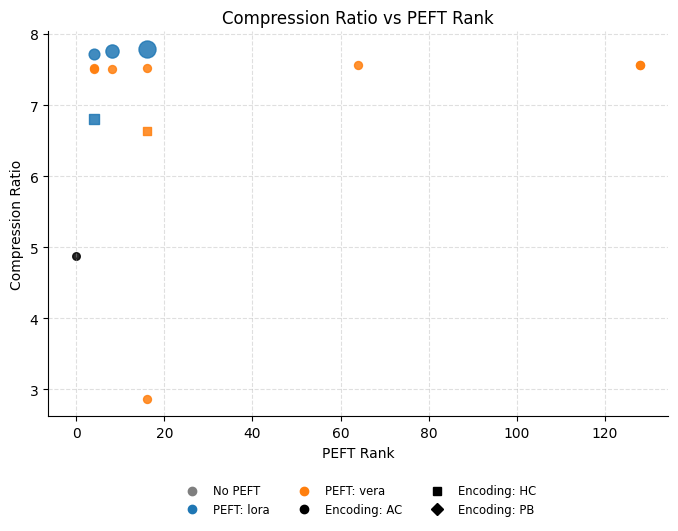

In [ ]:
# --- Setup ---
plt.figure(figsize=(8, 5))
ax = plt.gca()

# --- Normalize marker size by total_params for visibility ---
# Scale total_params to a reasonable marker size range (e.g., 30–150)
param_min = df['total_params'].min()
param_max = df['total_params'].max()
df['marker_size'] = 30 + 120 * (df['total_params'] - param_min) / (param_max - param_min + 1e-9)

# --- Plot each run ---
for _, r in df.iterrows():
    ax.scatter(
        r['rank'],                  # x-axis is now rank
        r[y_col],                   # y-axis is still your selected metric
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],       # size proportional to total_params
        alpha=0.85,
    )

    print(r['rank'], r[y_col], r['total_params'], r['encoding'])  # Debug print to check values

# --- Axis scales ---
if y_col in SCALES:
    ax.set_yscale(SCALES[y_col])

ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} vs PEFT Rank")

# --- Build legend ---
legend_elements = []

# PEFT colors
for peft, color in COLOR_BY_PEFT.items():
    label = f"PEFT: {peft}" if peft else "No PEFT"
    legend_elements.append(
        mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=6, label=label)
    )

# Encoding markers
for enc, marker in MARKER_BY_ENCODING.items():
    if enc is None:
        continue
    legend_elements.append(
        mlines.Line2D([], [], color='black', marker=marker, linestyle='None', markersize=6, label=f"Encoding: {enc}")
    )

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize='small'
)

# --- Grid and spines ---
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Save figure ---
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {save_path}")

plt.show()

Saved plot to plot.png


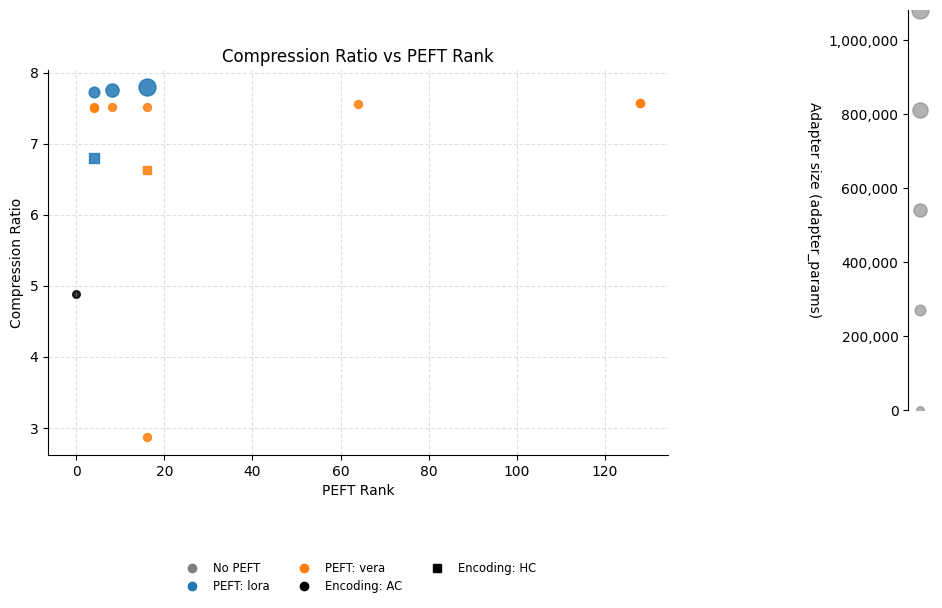

In [ ]:
# --- Setup main figure ---
fig, ax = plt.subplots(figsize=(8, 5))

# --- Define color/marker mappings ---
#COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}
#MARKER_BY_ENCODING = {"AC": "o", "HC": "s", None: "x"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()
df['marker_size'] = 30 + 120 * (df['adapter_params'] - param_min) / (param_max - param_min + 1e-9)


# --- Plot each run ---
for _, r in df.iterrows():
    #if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['total_params']):
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue
    ax.scatter(
        r['rank'],
        r[y_col],
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
    )

# --- Axis labels and title ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} vs PEFT Rank")

# --- Build color/encoding legend as before ---
legend_elements = []
for peft, color in COLOR_BY_PEFT.items():
    label = f"PEFT: {peft}" if peft else "No PEFT"
    legend_elements.append(
        plt.Line2D([], [], color=color, marker='o', linestyle='None', markersize=6, label=label)
    )
for enc, marker in MARKER_BY_ENCODING.items():
    if enc is None: continue
    legend_elements.append(
        plt.Line2D([], [], color='black', marker=marker, linestyle='None', markersize=6, label=f"Encoding: {enc}")
    )
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False, fontsize='small')

# --- Grid and spines ---
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Add vertical bubble size scale to the right ---
from matplotlib.ticker import FuncFormatter

# Create a secondary axes for the bubble scale
ax_scale = fig.add_axes([1.2, 0.2, 0.03, 0.8])  # [left, bottom, width, height]
ax_scale.set_xlim(0, 1)
ax_scale.set_ylim(param_min, param_max)

# Remove ticks and spines
ax_scale.get_xaxis().set_visible(False)
ax_scale.spines['top'].set_visible(False)
ax_scale.spines['right'].set_visible(False)
ax_scale.spines['bottom'].set_visible(False)

# Plot example bubbles for scale
n_steps = 5
scale_vals = np.linspace(param_min, param_max, n_steps)
for val in scale_vals:
    size = 30 + 120 * (val - param_min) / (param_max - param_min + 1e-9)
    ax_scale.scatter(0.5, val, s=size, color='gray', alpha=0.6)

# Format y-axis with commas
ax_scale.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_scale.set_ylabel("Adapter size (adapter_params)", rotation=270, labelpad=15)

# --- Save figure ---
if save_path:
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot to {save_path}")

plt.show()

Saved plot to plot.png


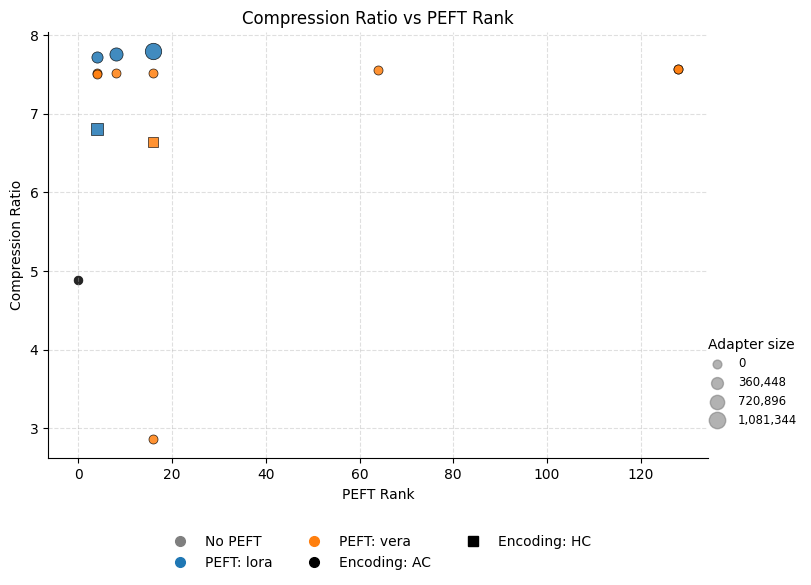

In [121]:
# --- Setup figure with automatic layout ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# --- Define color/marker mappings ---
COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}
MARKER_BY_ENCODING = {"AC": "o", "HC": "s", None: "x"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()

def size_fn(x):
    return 40 + 100 * (x - param_min) / (param_max - param_min + 1e-9)

df['marker_size'] = df['adapter_params'].apply(size_fn)

# --- Plot points ---
for _, r in df.iterrows():
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue
    ax.scatter(
        r['rank'],
        r[y_col],
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

# --- Labels ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} vs PEFT Rank")

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================

# --- Color legend (PEFT type) ---
color_legend = [
    Line2D([], [], color=color, marker='o', linestyle='None',
           markersize=7, label=f"PEFT: {peft}" if peft else "No PEFT")
    for peft, color in COLOR_BY_PEFT.items()
]

# --- Marker legend (Encoding) ---
marker_legend = [
    Line2D([], [], color='black', marker=marker, linestyle='None',
           markersize=7, label=f"Encoding: {enc}")
    for enc, marker in MARKER_BY_ENCODING.items()
    if enc is not None
]

# --- Bubble size legend ---
size_values = np.linspace(param_min, param_max, 4)
size_legend = [
    plt.scatter([], [], s=size_fn(val), color='gray', alpha=0.6,
                label=f"{int(val):,}")
    for val in size_values
]

# Add legends separately so they don't override each other
legend1 = ax.legend(
    handles=color_legend + marker_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

ax.add_artist(legend1)

legend2 = ax.legend(handles=size_legend,
                    title="Adapter size",
                    loc='lower right',
                    bbox_to_anchor=(1.15, 0.05),
                    ncol = 1,
                    frameon=False,
                    fontsize='small')

# --- Save figure ---
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {save_path}")

plt.show()